<a href="https://colab.research.google.com/github/PedroVentura21/DL-Proj2-base_bbbp/blob/main/2_BBBP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Célula 1: Importações e Configuração de Semente

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os
import time
import tensorflow as tf
from keras import layers, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.applications import EfficientNetB0, MobileNetV2
from keras.regularizers import l2

# REQUISITO TÉCNICO 3: Fixar a mesma semente aleatória para reprodutibilidade
SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("Versão do TensorFlow:", tf.__version__)
print("GPU Disponível:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.20.0
GPU Disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Célula 2: Carregamento de Dados (Atualizado para BBBP)

In [20]:
# Configuração de dimensões padrão
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Caminhos ajustados para o dataset BBBP
train_dir = 'drive/MyDrive/DL-Proj2/dataset_BBBP/train/'
val_dir   = 'drive/MyDrive/DL-Proj2/dataset_BBBP/val/'
test_dir  = 'drive/MyDrive/DL-Proj2/dataset_BBBP/test/'

# Criando os geradores de dados nativos
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False # Mantido False para garantir a consistência da Matriz de Confusão
)

# REQUISITO TÉCNICO 4: Normalização idêntica (divisão por 255.0 para escala [0, 1])
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

# Otimização para impedir gargalos de leitura de disco usando a GPU
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Dados do BBBP carregados com sucesso!")

Found 1625 files belonging to 2 classes.
Found 204 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Dados do BBBP carregados com sucesso!


### Célula 3: Callbacks

In [21]:
# REQUISITO 6.3: Callback customizado para medir o tempo médio por época
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()
    def on_epoch_end(self, epoch, logs={}):
        self.epoch_times.append(time.time() - self.epoch_time_start)

time_callback = TimeHistory()

# REQUISITO TÉCNICO 5: Callbacks obrigatórios de interrupção e salvamento de pesos
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=25,
    restore_best_weights=True
)

# CORREÇÃO KERAS 3: Adicionado '.weights.h5' obrigatório para save_weights_only=True
checkpoint_baseline = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_baseline_bbbp.weights.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    save_weights_only=True
)

checkpoint_finetuning = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_finetuning_bbbp.weights.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    save_weights_only=True
)

print("Callbacks de monitoramento atualizados e prontos!")

Callbacks de monitoramento atualizados e prontos!


### Data Augmentation

In [22]:
# Isto vai criar pequenas variações nas imagens durante o treino (rotação, zoom, espelhamento)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2), # Rotação aleatória até 20%
    layers.RandomZoom(0.1),     # Zoom aleatório até 10%
], name="data_augmentation")

### Célula 4: Construção e Compilação do Modelo Baseline

In [23]:
def build_baseline_cnn_robusto(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Injeção do Data Augmentation (só fica ativo durante o fit/treino)
        data_augmentation,

        # Bloco Convolucional 1
        # Adição do kernel_regularizer (L2) para evitar pesos excessivos
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2), # Dropout espacial suave inicial

        # Bloco Convolucional 2
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3), # Aumento progressivo do Dropout

        # Bloco Convolucional 3
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4), # Aumento progressivo do Dropout

        # Cabeçalho de Classificação
        layers.Flatten(),
        layers.Dense(256, kernel_regularizer=l2(0.002)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5), # Dropout severo de 60% para regularização final

        layers.Dense(1, activation='sigmoid')
    ])
    return model

baseline_model = build_baseline_cnn_robusto()

# Compilação do modelo
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,805,249 (98.44 MB)

 Trainable params: 25,804,225 (98.44 MB)

 Non-trainable params: 1,024 (4.00 KB)

### Extraindo rótulos do dataset de treino para calcular pesos

In [24]:
print("Extraindo rótulos do dataset de treino para calcular pesos...")
# Percorre o dataset de treino e empilha todos os rótulos (y)
y_train = np.concatenate([y for x, y in train_dataset], axis=0)

# Contagem
total = len(y_train)
pos = np.sum(y_train == 1) # Classe 1
neg = total - pos          # Classe 0

print(f"Total de imagens: {total}")
print(f"Classe 0 (Negativos): {neg}")
print(f"Classe 1 (Positivos): {pos}")

# Fórmula heurística padrão para balanceamento
# O peso é inversamente proporcional à frequência da classe
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)

Extraindo rótulos do dataset de treino para calcular pesos...
Total de imagens: 1625
Classe 0 (Negativos): 399
Classe 1 (Positivos): 1226


In [25]:
# Dicionário no formato exigido pelo Keras

class_weight_dict = {
    0: weight_for_0,
    1: weight_for_1
}

# class_weight_dict = {
#     0: np.float64(2),
#     1: np.float64(0.6)
# }

print(f"Pesos de Classe calculados: {class_weight_dict}")

Pesos de Classe calculados: {0: np.float64(2.036340852130326), 1: np.float64(0.6627243066884176)}


### Treinamento do Baseline

In [26]:
print("Iniciando treinamento do modelo Baseline (BBBP)...")
history_baseline = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint_baseline, time_callback]
)

# Armazenando os tempos calculados para a tabela final
baseline_epoch_times = time_callback.epoch_times
baseline_total_time = sum(baseline_epoch_times)
print(f"Treinamento concluído! Tempo total: {baseline_total_time:.2f}s")

Iniciando treinamento do modelo Baseline (BBBP)...
Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 323ms/step - accuracy: 0.5397 - auc: 0.5520 - loss: 2.1849 - val_accuracy: 0.1961 - val_auc: 0.4793 - val_loss: 2.9776
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 286ms/step - accuracy: 0.5428 - auc: 0.5797 - loss: 2.0348 - val_accuracy: 0.1961 - val_auc: 0.4990 - val_loss: 2.5213
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 263ms/step - accuracy: 0.5803 - auc: 0.6067 - loss: 1.9429 - val_accuracy: 0.1961 - val_auc: 0.4768 - val_loss: 2.0722
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 260ms/step - accuracy: 0.5588 - auc: 0.5961 - loss: 1.9428 - val_accuracy: 0.2206 - val_auc: 0.4866 - val_loss: 1.8668
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 258ms/step - accuracy: 0.5871 - auc: 0.6411 - loss: 1.8700 - val_accuracy: 0.3529 - val_auc: 0.4575 - val_loss: 1.8318
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 267ms/step - accuracy: 0.5803 - auc: 0.6283 - loss: 1.8678 - val_accuracy: 0.2549 - val_auc: 0.4

### Matriz de confusão

In [27]:
# Extrai os rótulos reais (y_true) uma única vez para usar em todo o notebook
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Rótulos para o gráfico
labels_bbbp = ['Não Penetra (0)', 'Penetra (1)']

Avaliando o modelo Baseline no conjunto de Teste...

=== RESULTADOS BASELINE (BBBP) ===
Acurácia Teste: 0.5050 | AUC-ROC Teste: 0.8179


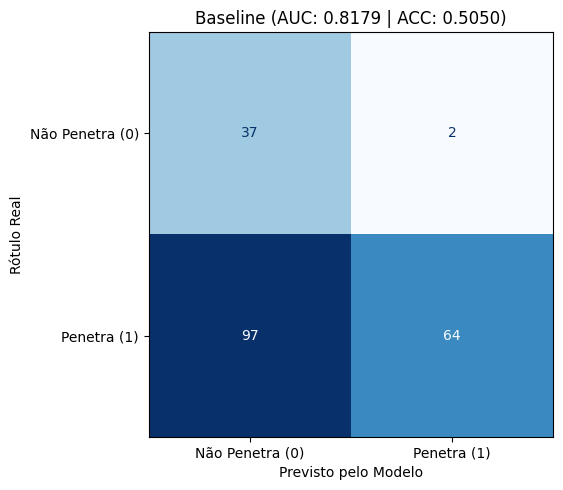

In [28]:
# Carrega os melhores pesos do modelo do zero
baseline_model.load_weights('best_baseline_bbbp.weights.h5')

# Extração de métricas de teste
print("Avaliando o modelo Baseline no conjunto de Teste...")
loss_base, acc_base, auc_base = baseline_model.evaluate(test_dataset, verbose=0)

# Predições do Baseline
pred_base = baseline_model.predict(test_dataset, verbose=0)
cm_base = confusion_matrix(y_true, (pred_base > 0.5).astype(int))

print("\n=== RESULTADOS BASELINE (BBBP) ===")
print(f"Acurácia Teste: {acc_base:.4f} | AUC-ROC Teste: {auc_base:.4f}")

# Plotagem da Matriz de Confusão em Imagem
plt.figure(figsize=(6, 5))
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=labels_bbbp)
disp_base.plot(ax=plt.gca(), cmap='Blues', values_format='d', colorbar=False)
plt.title(f'Baseline (AUC: {auc_base:.4f} | ACC: {acc_base:.4f})')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Rótulo Real')
plt.tight_layout()
plt.show()

### Gráficos de Aprendizado

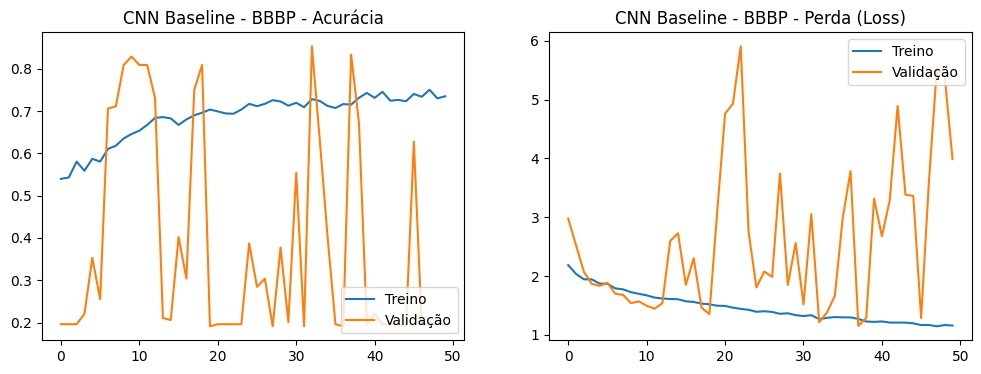

In [29]:
def plot_learning_curves(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Treino')
    plt.plot(epochs_range, val_acc, label='Validação')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Acurácia')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Treino')
    plt.plot(epochs_range, val_loss, label='Validação')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Perda (Loss)')
    plt.show()

plot_learning_curves(history_baseline, "CNN Baseline - BBBP")

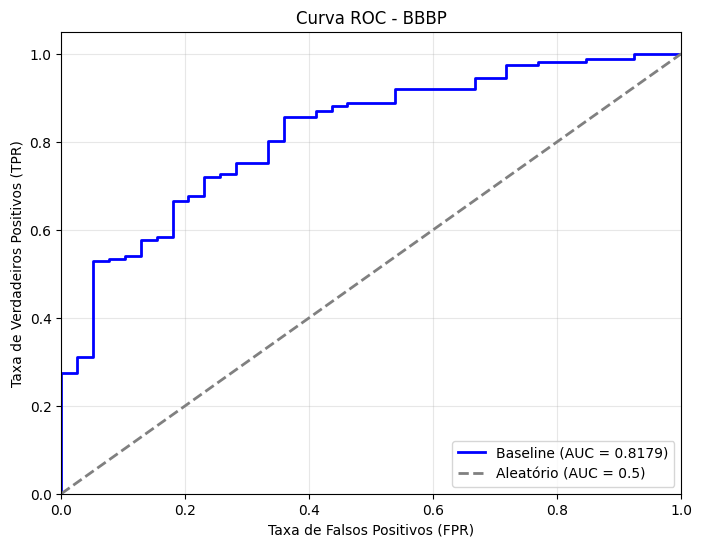

In [30]:
from sklearn.metrics import roc_curve, auc

# Calcula as taxas (FPR e TPR) e os limiares para ambos os modelos
fpr_base, tpr_base, _ = roc_curve(y_true, pred_base)

# Plota o gráfico
plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, color='blue', lw=2, label=f'Baseline (AUC = {auc_base:.4f})')

# Linha de aposta aleatória (o pior cenário possível, AUC = 0.5)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Aleatório (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - BBBP')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Célula 6: Construção do Modelo Fine-Tuning (EfficientNetB0)

In [31]:
def build_finetuned_model(input_shape=(224, 224, 3)):
    # Carregando backbone sem o topo original do ImageNet
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # ESTRATÉGIA FASE 1: Congelar pesos originais
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return base_model, model

base_model, finetuning_model = build_finetuned_model()

# Compilação Estágio 1 (Warmup)
finetuning_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

finetuning_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,385 (8.64 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

### Célula 7: Treinamento do Fine-Tuning (Fase 1 e Fase 2)

In [ ]:
# Instanciando um medidor de tempo exclusivo para o Fine-Tuning
time_callback_ft = TimeHistory()

print("Iniciando Estágio 1 (Warmup) do Fine-Tuning...")
finetuning_model.fit(
    train_dataset,
    class_weight=class_weight_dict,
    validation_data=val_dataset,
    epochs=7, # Poucas épocas para estabilizar o topo densificador
    callbacks=[early_stop, time_callback_ft]
)

print("\nEstágio 1 concluído. Liberando camadas superiores para ajuste de domínio...")
# ESTRATÉGIA FASE 2: Descongelar as últimas 20 camadas do backbone
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompilação obrigatória com taxa de aprendizado reduzida
finetuning_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("Iniciando Estágio 2 (Fine-Tuning Ativo - BBBP)...")
history_finetuning = finetuning_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=53,
    callbacks=[early_stop, checkpoint_finetuning, time_callback_ft]
)

ft_epoch_times = time_callback_ft.epoch_times
ft_total_time = sum(ft_epoch_times)
print(f"Treinamento do Fine-Tuning concluído! Tempo total: {ft_total_time:.2f}s")

Iniciando Estágio 1 (Warmup) do Fine-Tuning...
Epoch 1/7
51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.6228 - auc: 0.6944 - loss: 0.7213 - val_accuracy: 0.6324 - val_auc: 0.6152 - val_loss: 0.6419
Epoch 2/7
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.7157 - auc: 0.7956 - loss: 0.5715 - val_accuracy: 0.6471 - val_auc: 0.6511 - val_loss: 0.6387
Epoch 3/7
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.7403 - auc: 0.8151 - loss: 0.5475 - val_accuracy: 0.6422 - val_auc: 0.6873 - val_loss: 0.6737
Epoch 4/7
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.7218 - auc: 0.8079 - loss: 0.5620 - val_accuracy: 0.6324 - val_auc: 0.6984 - val_loss: 0.7339
Epoch 5/7
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.7465 - auc: 0.8177 - loss: 0.5390 - val_accuracy: 0.6275 - val_auc: 0.7090 - val_loss: 0.6905
Epoch 6/7
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.7428 - auc: 0.8230 - loss: 0.5321 - val_accuracy: 0.6324 - val_auc: 0.7290 - val_loss: 0.671

### Avaliação e Matriz de Confusão

In [ ]:
# Carrega os melhores pesos do modelo pré-treinado
finetuning_model.load_weights('best_finetuning_bbbp.weights.h5')

# Extração de métricas de teste
print("Avaliando o modelo Fine-Tuning no conjunto de Teste...")
loss_ft, acc_ft, auc_ft = finetuning_model.evaluate(test_dataset, verbose=0)

# Predições do Fine-Tuning (usando o y_true extraído na célula do Baseline)
pred_ft = finetuning_model.predict(test_dataset, verbose=0)
cm_ft = confusion_matrix(y_true, (pred_ft > 0.5).astype(int))

print("\n=== RESULTADOS FINE-TUNING (BBBP) ===")
print(f"Acurácia Teste: {acc_ft:.4f} | AUC-ROC Teste: {auc_ft:.4f}")

# Plotagem da Matriz de Confusão em Imagem
plt.figure(figsize=(6, 5))
disp_ft = ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=labels_bbbp)
disp_ft.plot(ax=plt.gca(), cmap='Oranges', values_format='d', colorbar=False)
plt.title(f'Fine-Tuning (AUC: {auc_ft:.4f})')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Rótulo Real')
plt.tight_layout()
plt.show()

### Gráficos de Aprendizado

In [ ]:
plot_learning_curves(history_finetuning, "Fine-Tuning EfficientNetB0 - BBBP")

### Graf. curva ROC

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calcula as taxas (FPR e TPR) e os limiares para ambos os modelos
fpr_base, tpr_base, _ = roc_curve(y_true, pred_base)
fpr_ft, tpr_ft, _ = roc_curve(y_true, pred_ft)

# Plota o gráfico
plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, color='blue', lw=2, label=f'Baseline (AUC = {auc_base:.4f})')
plt.plot(fpr_ft, tpr_ft, color='darkorange', lw=2, label=f'Fine-Tuning (AUC = {auc_ft:.4f})')

# Linha de aposta aleatória (o pior cenário possível, AUC = 0.5)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Aleatório (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - BBBP')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Tabela Comparativa (Atualizada para BBBP)

In [ ]:
# Coleta das acurácias finais obtidas no último passo válido do histórico
acc_train_base = history_baseline.history['accuracy'][-1]
acc_train_ft = history_finetuning.history['accuracy'][-1]

data = {
    'Dataset': ['BBBP', 'BBBP'],
    'Modelo': ['Baseline (Do Zero)', 'Fine-tuning (EfficientNetB0)'],
    'Acurácia Treino': [f"{acc_train_base:.4f}", f"{acc_train_ft:.4f}"],
    'Acurácia Teste': [f"{acc_base:.4f}", f"{acc_ft:.4f}"],
    'AUC-ROC (Teste)': [f"{auc_base:.4f}", f"{auc_ft:.4f}"],
    'Tempo Médio/Época (s)': [f"{np.mean(baseline_epoch_times):.2f}", f"{np.mean(ft_epoch_times):.2f}"],
    'Tempo Total (s)': [f"{baseline_total_time:.2f}", f"{ft_total_time:.2f}"]
}

df_comparativo = pd.DataFrame(data)
df_comparativo